# Market Risk Analytics Platform

## Notebook 03 — Value-at-Risk and Expected Shortfall

### Objectives

This notebook estimates the market risk of the multi-asset portfolio constructed in Notebook 02.

It implements and compares:

- Historical Value-at-Risk;
- Gaussian Parametric Value-at-Risk;
- Student-t Parametric Value-at-Risk;
- Monte Carlo Value-at-Risk;
- EWMA Value-at-Risk;
- Historical Expected Shortfall;
- Gaussian Expected Shortfall;
- Student-t Expected Shortfall;
- Monte Carlo Expected Shortfall;
- rolling one-day-ahead risk forecasts.

### Pipeline dependencies

This notebook depends on the successful execution of:

- Notebook 01 — Data Collection and Market Analysis;
- Notebook 02 — Portfolio Construction and P&L Analysis.

The rolling forecasts generated here will be used by:

- Notebook 04 — VaR Backtesting and Stress Testing.

### Monter Google Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


### Installer les bibliothèques nécessaires

In [ ]:
!pip install -q scipy pyarrow

### Définir les chemins

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/market-risk-analytics"
)

CONFIG_DIR = PROJECT_ROOT / "config"
DATA_PROCESSED_DIR = (
    PROJECT_ROOT / "data" / "processed"
)
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures"
SRC_DIR = PROJECT_ROOT / "src"

for directory in [
    CONFIG_DIR,
    DATA_PROCESSED_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    SRC_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /content/drive/MyDrive/market-risk-analytics


### Importer les bibliothèques

In [ ]:
from datetime import datetime, timezone
import hashlib
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import norm, t

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.6f}",
)

RANDOM_SEED = 42
TRADING_DAYS_PER_YEAR = 252

np.random.seed(RANDOM_SEED)

## Vérification des dépendances du notebook 2

### Définir les fichiers requis

In [ ]:
NOTEBOOK_02_REQUIRED_FILES = {
    "portfolio_timeseries": (
        DATA_PROCESSED_DIR
        / "portfolio_timeseries.parquet"
    ),

    "portfolio_weights": (
        DATA_PROCESSED_DIR
        / "portfolio_weights.csv"
    ),

    "portfolio_positions": (
        DATA_PROCESSED_DIR
        / "portfolio_positions.csv"
    ),

    "asset_pnl": (
        DATA_PROCESSED_DIR
        / "asset_pnl_contributions.parquet"
    ),

    "manifest": (
        CONFIG_DIR
        / "notebook_02_manifest.json"
    ),
}

### Vérifier l’existence des fichiers

In [ ]:
def validate_required_files(
    required_files: dict[str, Path],
) -> None:
    """Validate upstream notebook files."""

    missing_files = [
        file_path
        for file_path in required_files.values()
        if not file_path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Notebook 02 must be executed first. "
            f"Missing files: {missing_files}"
        )

    empty_files = [
        file_path
        for file_path in required_files.values()
        if file_path.stat().st_size == 0
    ]

    if empty_files:
        raise ValueError(
            "Empty dependency files detected: "
            f"{empty_files}"
        )

    print(
        "All Notebook 02 dependency files "
        "are available."
    )


validate_required_files(
    NOTEBOOK_02_REQUIRED_FILES
)

All Notebook 02 dependency files are available.


### Charger le manifeste du notebook 2

In [ ]:
with open(
    NOTEBOOK_02_REQUIRED_FILES["manifest"],
    "r",
    encoding="utf-8",
) as manifest_file:
    notebook_02_manifest = json.load(
        manifest_file
    )

if notebook_02_manifest.get("status") != "SUCCESS":
    raise RuntimeError(
        "Notebook 02 did not complete successfully."
    )

expected_producer = (
    "02_portfolio_and_pnl_analysis.ipynb"
)

if (
    notebook_02_manifest.get("producer_notebook")
    != expected_producer
):
    raise RuntimeError(
        "Unexpected producer notebook "
        "in Notebook 02 manifest."
    )

print("Notebook 02 manifest validated.")
print(
    "Portfolio:",
    notebook_02_manifest["portfolio_name"],
)
print(
    "Initial portfolio value:",
    notebook_02_manifest[
        "initial_portfolio_value"
    ],
)
print(
    "Observation period:",
    notebook_02_manifest["actual_start_date"],
    "to",
    notebook_02_manifest["actual_end_date"],
)

Notebook 02 manifest validated.
Portfolio: Global Multi-Asset Risk Portfolio
Initial portfolio value: 1000000.0
Observation period: 2018-01-02 to 2026-07-29


###  Vérifier les empreintes SHA-256

In [ ]:
def calculate_file_hash(
    file_path: Path,
) -> str:
    """Calculate the SHA-256 hash of a file."""

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(8192),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()

In [ ]:
expected_hashes = notebook_02_manifest.get(
    "file_hashes",
    {},
)

files_to_verify = {
    "portfolio_timeseries.parquet":
        NOTEBOOK_02_REQUIRED_FILES[
            "portfolio_timeseries"
        ],

    "portfolio_weights.csv":
        NOTEBOOK_02_REQUIRED_FILES[
            "portfolio_weights"
        ],

    "portfolio_positions.csv":
        NOTEBOOK_02_REQUIRED_FILES[
            "portfolio_positions"
        ],

    "asset_pnl_contributions.parquet":
        NOTEBOOK_02_REQUIRED_FILES[
            "asset_pnl"
        ],
}

hash_validation_results = {}

for file_name, file_path in files_to_verify.items():
    calculated_hash = calculate_file_hash(
        file_path
    )

    expected_hash = expected_hashes.get(
        file_name
    )

    hash_validation_results[file_name] = {
        "expected_hash": expected_hash,
        "calculated_hash": calculated_hash,
        "is_valid": (
            calculated_hash == expected_hash
            if expected_hash is not None
            else None
        ),
    }

hash_validation_results

{'portfolio_timeseries.parquet': {'expected_hash': '8ad5b57011be9abe8da80b2ac2a055acb3a344a7fd88ae806c42aa8252f2f5f1',
  'calculated_hash': '8ad5b57011be9abe8da80b2ac2a055acb3a344a7fd88ae806c42aa8252f2f5f1',
  'is_valid': True},
 'portfolio_weights.csv': {'expected_hash': '30770211096b759793962fb08d9985f0005e49940526f38bf1a86b5f187fdfd8',
  'calculated_hash': '30770211096b759793962fb08d9985f0005e49940526f38bf1a86b5f187fdfd8',
  'is_valid': True},
 'portfolio_positions.csv': {'expected_hash': '69b82696d83bef987a317995150b37f56c8319f8aa00bac280ca75fcc830ba3c',
  'calculated_hash': '69b82696d83bef987a317995150b37f56c8319f8aa00bac280ca75fcc830ba3c',
  'is_valid': True},
 'asset_pnl_contributions.parquet': {'expected_hash': 'a9b4889091733ab17b0afc2c379d13e23fbd14b1e6dec7e59b1659dd013055a1',
  'calculated_hash': 'a9b4889091733ab17b0afc2c379d13e23fbd14b1e6dec7e59b1659dd013055a1',
  'is_valid': True}}

In [ ]:
invalid_hashes = [
    file_name
    for file_name, result
    in hash_validation_results.items()
    if result["is_valid"] is False
]

if invalid_hashes:
    raise RuntimeError(
        "The following Notebook 02 files "
        "were modified after generation: "
        f"{invalid_hashes}"
    )

print("Notebook 02 file integrity validated.")

Notebook 02 file integrity validated.


## Chargement des données

### Charger les données du portefeuille

In [ ]:
portfolio_timeseries = pd.read_parquet(
    NOTEBOOK_02_REQUIRED_FILES[
        "portfolio_timeseries"
    ]
)

portfolio_weights = pd.read_csv(
    NOTEBOOK_02_REQUIRED_FILES[
        "portfolio_weights"
    ],
    index_col=0,
).squeeze("columns")

portfolio_positions = pd.read_csv(
    NOTEBOOK_02_REQUIRED_FILES[
        "portfolio_positions"
    ],
    index_col=0,
)

asset_pnl_contributions = pd.read_parquet(
    NOTEBOOK_02_REQUIRED_FILES[
        "asset_pnl"
    ]
)

portfolio_timeseries.index = pd.to_datetime(
    portfolio_timeseries.index
)

asset_pnl_contributions.index = pd.to_datetime(
    asset_pnl_contributions.index
)

portfolio_timeseries.index.name = "date"
asset_pnl_contributions.index.name = "date"

print(
    "Portfolio time series:",
    portfolio_timeseries.shape,
)

print(
    "Asset P&L contributions:",
    asset_pnl_contributions.shape,
)

Portfolio time series: (2233, 7)
Asset P&L contributions: (2233, 6)


### Extraire les séries principales

In [ ]:
portfolio_value = (
    portfolio_timeseries[
        "portfolio_value"
    ]
    .astype(float)
)

portfolio_returns = (
    portfolio_timeseries[
        "portfolio_return"
    ]
    .astype(float)
    .dropna()
)

portfolio_daily_pnl = (
    portfolio_timeseries[
        "daily_pnl"
    ]
    .astype(float)
    .dropna()
)

portfolio_value.name = "portfolio_value"
portfolio_returns.name = "portfolio_return"
portfolio_daily_pnl.name = "daily_pnl"

print(
    "Return observations:",
    len(portfolio_returns),
)

print(
    "P&L observations:",
    len(portfolio_daily_pnl),
)

Return observations: 2232
P&L observations: 2232


### Contrôler les données chargées

In [ ]:
def validate_risk_input_data(
    portfolio_value: pd.Series,
    portfolio_returns: pd.Series,
    daily_pnl: pd.Series,
) -> None:
    """Validate risk-model input data."""

    if portfolio_value.empty:
        raise ValueError(
            "Portfolio value series is empty."
        )

    if portfolio_returns.empty:
        raise ValueError(
            "Portfolio return series is empty."
        )

    if daily_pnl.empty:
        raise ValueError(
            "Daily P&L series is empty."
        )

    for series_name, series in {
        "portfolio_value": portfolio_value,
        "portfolio_returns": portfolio_returns,
        "daily_pnl": daily_pnl,
    }.items():

        if series.isna().any():
            raise ValueError(
                f"{series_name} contains missing values."
            )

        if not np.isfinite(
            series.to_numpy()
        ).all():
            raise ValueError(
                f"{series_name} contains "
                "non-finite values."
            )

    if portfolio_value.le(0).any():
        raise ValueError(
            "Portfolio values must be positive."
        )

    common_index = (
        portfolio_returns.index
        .intersection(daily_pnl.index)
    )

    if len(common_index) == 0:
        raise ValueError(
            "Portfolio return and P&L series "
            "are not aligned."
        )

    print("Risk input data validation successful.")


validate_risk_input_data(
    portfolio_value=portfolio_value,
    portfolio_returns=portfolio_returns,
    daily_pnl=portfolio_daily_pnl,
)

Risk input data validation successful.


## Paramètres des modèles de risque

### Configuration

In [ ]:
CONFIDENCE_LEVELS = [
    0.95,
    0.975,
    0.99,
]

PRIMARY_CONFIDENCE_LEVEL = 0.99

HISTORICAL_WINDOW = 250

EWMA_DECAY_FACTOR = 0.94

MONTE_CARLO_SIMULATIONS = 100_000

RISK_HORIZON_DAYS = 1

CURRENT_PORTFOLIO_VALUE = float(
    portfolio_value.iloc[-1]
)

print(
    "Current portfolio value:",
    f"{CURRENT_PORTFOLIO_VALUE:,.2f}",
)

print(
    "Primary confidence level:",
    f"{PRIMARY_CONFIDENCE_LEVEL:.1%}",
)

Current portfolio value: 1,999,432.66
Primary confidence level: 99.0%


## Convention utilisée pour la VaR

## Risk-measure convention

The models estimate the potential loss over a one-day horizon.

For a portfolio return \(R\), the Value-at-Risk at confidence level \(c\) is defined as:

\[
VaR_c = -Q_{1-c}(R) \times V
\]

where:

- \(Q_{1-c}(R)\) is the lower-tail return quantile;
- \(V\) is the portfolio market value;
- VaR is reported as a positive monetary loss.

Expected Shortfall is defined as the average loss conditional on the return being below the VaR quantile:

\[
ES_c =
-E\left[
R \mid R \leq Q_{1-c}(R)
\right]
\times V
\]

A positive VaR or Expected Shortfall therefore represents a potential loss.

## Fonctions communes de validation

### Validation des paramètres

In [ ]:
def validate_risk_parameters(
    returns: pd.Series,
    confidence_level: float,
    portfolio_value: float,
) -> pd.Series:
    """Validate common VaR and ES inputs."""

    clean_returns = (
        pd.Series(returns)
        .dropna()
        .astype(float)
    )

    if clean_returns.empty:
        raise ValueError(
            "Return series cannot be empty."
        )

    if not np.isfinite(
        clean_returns.to_numpy()
    ).all():
        raise ValueError(
            "Return series contains "
            "non-finite values."
        )

    if not 0 < confidence_level < 1:
        raise ValueError(
            "Confidence level must be "
            "between zero and one."
        )

    if portfolio_value <= 0:
        raise ValueError(
            "Portfolio value must be positive."
        )

    return clean_returns

## VaR historique

### Fonction de VaR historique

In [ ]:
def historical_var(
    returns: pd.Series,
    confidence_level: float,
    portfolio_value: float,
) -> dict:
    """Estimate historical Value-at-Risk."""

    clean_returns = validate_risk_parameters(
        returns=returns,
        confidence_level=confidence_level,
        portfolio_value=portfolio_value,
    )

    alpha = 1 - confidence_level

    return_quantile = float(
        clean_returns.quantile(alpha)
    )

    var_return = max(
        -return_quantile,
        0.0,
    )

    var_amount = (
        var_return
        * portfolio_value
    )

    return {
        "model": "Historical",
        "confidence_level": confidence_level,
        "return_quantile": return_quantile,
        "var_return": var_return,
        "var_amount": var_amount,
        "sample_size": len(clean_returns),
    }

###  Fonction d’Expected Shortfall historique

In [ ]:
def historical_expected_shortfall(
    returns: pd.Series,
    confidence_level: float,
    portfolio_value: float,
) -> dict:
    """Estimate historical Expected Shortfall."""

    clean_returns = validate_risk_parameters(
        returns=returns,
        confidence_level=confidence_level,
        portfolio_value=portfolio_value,
    )

    alpha = 1 - confidence_level

    return_quantile = float(
        clean_returns.quantile(alpha)
    )

    tail_returns = clean_returns[
        clean_returns <= return_quantile
    ]

    if tail_returns.empty:
        raise ValueError(
            "No observations were found "
            "in the historical tail."
        )

    expected_tail_return = float(
        tail_returns.mean()
    )

    es_return = max(
        -expected_tail_return,
        0.0,
    )

    es_amount = (
        es_return
        * portfolio_value
    )

    return {
        "model": "Historical",
        "confidence_level": confidence_level,
        "return_quantile": return_quantile,
        "expected_tail_return":
            expected_tail_return,
        "es_return": es_return,
        "es_amount": es_amount,
        "tail_observations":
            len(tail_returns),
        "sample_size":
            len(clean_returns),
    }

## VaR paramétrique normale

### Fonction de VaR gaussienne

In [ ]:
def gaussian_var(
    returns: pd.Series,
    confidence_level: float,
    portfolio_value: float,
) -> dict:
    """Estimate Gaussian parametric VaR."""

    clean_returns = validate_risk_parameters(
        returns=returns,
        confidence_level=confidence_level,
        portfolio_value=portfolio_value,
    )

    alpha = 1 - confidence_level

    mean_return = float(
        clean_returns.mean()
    )

    volatility = float(
        clean_returns.std(ddof=1)
    )

    z_alpha = float(
        norm.ppf(alpha)
    )

    return_quantile = (
        mean_return
        + volatility * z_alpha
    )

    var_return = max(
        -return_quantile,
        0.0,
    )

    var_amount = (
        var_return
        * portfolio_value
    )

    return {
        "model": "Gaussian",
        "confidence_level": confidence_level,
        "mean_return": mean_return,
        "volatility": volatility,
        "return_quantile": return_quantile,
        "var_return": var_return,
        "var_amount": var_amount,
        "sample_size": len(clean_returns),
    }

### Expected Shortfall gaussien

In [ ]:
def gaussian_expected_shortfall(
    returns: pd.Series,
    confidence_level: float,
    portfolio_value: float,
) -> dict:
    """Estimate Gaussian Expected Shortfall."""

    clean_returns = validate_risk_parameters(
        returns=returns,
        confidence_level=confidence_level,
        portfolio_value=portfolio_value,
    )

    alpha = 1 - confidence_level

    mean_return = float(
        clean_returns.mean()
    )

    volatility = float(
        clean_returns.std(ddof=1)
    )

    z_alpha = float(
        norm.ppf(alpha)
    )

    tail_density = float(
        norm.pdf(z_alpha)
    )

    expected_tail_return = (
        mean_return
        - volatility
        * tail_density
        / alpha
    )

    es_return = max(
        -expected_tail_return,
        0.0,
    )

    es_amount = (
        es_return
        * portfolio_value
    )

    return {
        "model": "Gaussian",
        "confidence_level": confidence_level,
        "mean_return": mean_return,
        "volatility": volatility,
        "expected_tail_return":
            expected_tail_return,
        "es_return": es_return,
        "es_amount": es_amount,
        "sample_size": len(clean_returns),
    }

### Distribution Student-t

La distribution Student-t permet de mieux représenter les queues épaisses souvent observées dans les rendements financiers.

### Ajuster la distribution Student-t

In [ ]:
def fit_student_t_distribution(
    returns: pd.Series,
) -> dict:
    """Fit a Student-t distribution to returns."""

    clean_returns = (
        pd.Series(returns)
        .dropna()
        .astype(float)
    )

    if len(clean_returns) < 30:
        raise ValueError(
            "At least 30 observations are required "
            "to fit a Student-t distribution."
        )

    degrees_of_freedom, location, scale = (
        stats.t.fit(clean_returns)
    )

    if degrees_of_freedom <= 1:
        raise ValueError(
            "The fitted Student-t distribution "
            "does not have a finite mean."
        )

    if scale <= 0:
        raise ValueError(
            "The fitted Student-t scale "
            "must be positive."
        )

    return {
        "degrees_of_freedom":
            float(degrees_of_freedom),
        "location":
            float(location),
        "scale":
            float(scale),
    }


student_t_parameters = (
    fit_student_t_distribution(
        portfolio_returns
    )
)

student_t_parameters

{'degrees_of_freedom': 3.3244089813793583,
 'location': 0.0005291370949287845,
 'scale': 0.004243915932818188}

### VaR Student-t

In [ ]:
def student_t_var(
    returns: pd.Series,
    confidence_level: float,
    portfolio_value: float,
) -> dict:
    """Estimate Student-t parametric VaR."""

    clean_returns = validate_risk_parameters(
        returns=returns,
        confidence_level=confidence_level,
        portfolio_value=portfolio_value,
    )

    parameters = fit_student_t_distribution(
        clean_returns
    )

    alpha = 1 - confidence_level

    df = parameters[
        "degrees_of_freedom"
    ]

    location = parameters["location"]
    scale = parameters["scale"]

    standardized_quantile = float(
        t.ppf(alpha, df=df)
    )

    return_quantile = (
        location
        + scale
        * standardized_quantile
    )

    var_return = max(
        -return_quantile,
        0.0,
    )

    var_amount = (
        var_return
        * portfolio_value
    )

    return {
        "model": "Student-t",
        "confidence_level":
            confidence_level,
        "degrees_of_freedom":
            df,
        "location":
            location,
        "scale":
            scale,
        "return_quantile":
            return_quantile,
        "var_return":
            var_return,
        "var_amount":
            var_amount,
        "sample_size":
            len(clean_returns),
    }

### Expected Shortfall Student-t

In [ ]:
def student_t_expected_shortfall(
    returns: pd.Series,
    confidence_level: float,
    portfolio_value: float,
) -> dict:
    """Estimate Student-t Expected Shortfall."""

    clean_returns = validate_risk_parameters(
        returns=returns,
        confidence_level=confidence_level,
        portfolio_value=portfolio_value,
    )

    parameters = fit_student_t_distribution(
        clean_returns
    )

    alpha = 1 - confidence_level

    df = parameters[
        "degrees_of_freedom"
    ]

    location = parameters["location"]
    scale = parameters["scale"]

    if df <= 1:
        raise ValueError(
            "Student-t Expected Shortfall "
            "requires degrees of freedom above one."
        )

    q_alpha = float(
        t.ppf(alpha, df=df)
    )

    density_at_quantile = float(
        t.pdf(q_alpha, df=df)
    )

    standardized_tail_mean = (
        -(
            df + q_alpha**2
        )
        / (
            df - 1
        )
        * density_at_quantile
        / alpha
    )

    expected_tail_return = (
        location
        + scale
        * standardized_tail_mean
    )

    es_return = max(
        -expected_tail_return,
        0.0,
    )

    es_amount = (
        es_return
        * portfolio_value
    )

    return {
        "model": "Student-t",
        "confidence_level":
            confidence_level,
        "degrees_of_freedom":
            df,
        "location":
            location,
        "scale":
            scale,
        "expected_tail_return":
            expected_tail_return,
        "es_return":
            es_return,
        "es_amount":
            es_amount,
        "sample_size":
            len(clean_returns),
    }

## Simulation Monte Carlo

### Fonction Monte Carlo

In [ ]:
def monte_carlo_var_es(
    returns: pd.Series,
    confidence_level: float,
    portfolio_value: float,
    number_of_simulations: int = 100_000,
    random_seed: int = 42,
) -> dict:
    """
    Estimate VaR and ES using Student-t Monte Carlo simulation.
    """

    clean_returns = validate_risk_parameters(
        returns=returns,
        confidence_level=confidence_level,
        portfolio_value=portfolio_value,
    )

    if number_of_simulations < 10_000:
        raise ValueError(
            "At least 10,000 simulations "
            "are recommended."
        )

    parameters = fit_student_t_distribution(
        clean_returns
    )

    rng = np.random.default_rng(
        random_seed
    )

    simulated_returns = t.rvs(
        df=parameters[
            "degrees_of_freedom"
        ],
        loc=parameters[
            "location"
        ],
        scale=parameters[
            "scale"
        ],
        size=number_of_simulations,
        random_state=rng,
    )

    alpha = 1 - confidence_level

    return_quantile = float(
        np.quantile(
            simulated_returns,
            alpha,
        )
    )

    tail_returns = simulated_returns[
        simulated_returns
        <= return_quantile
    ]

    expected_tail_return = float(
        tail_returns.mean()
    )

    var_return = max(
        -return_quantile,
        0.0,
    )

    es_return = max(
        -expected_tail_return,
        0.0,
    )

    return {
        "model": "Monte Carlo Student-t",
        "confidence_level":
            confidence_level,
        "number_of_simulations":
            number_of_simulations,
        "return_quantile":
            return_quantile,
        "expected_tail_return":
            expected_tail_return,
        "var_return":
            var_return,
        "var_amount":
            var_return
            * portfolio_value,
        "es_return":
            es_return,
        "es_amount":
            es_return
            * portfolio_value,
        "degrees_of_freedom":
            parameters[
                "degrees_of_freedom"
            ],
        "location":
            parameters["location"],
        "scale":
            parameters["scale"],
    }

## VaR EWMA

### Fonction de volatilité EWMA

In [ ]:
def calculate_ewma_volatility(
    returns: pd.Series,
    decay_factor: float = 0.94,
) -> pd.Series:
    """Calculate EWMA volatility series."""

    clean_returns = (
        pd.Series(returns)
        .dropna()
        .astype(float)
    )

    if not 0 < decay_factor < 1:
        raise ValueError(
            "EWMA decay factor must be "
            "between zero and one."
        )

    if len(clean_returns) < 30:
        raise ValueError(
            "At least 30 observations "
            "are required."
        )

    initial_variance = float(
        clean_returns.iloc[:30].var(
            ddof=1
        )
    )

    ewma_variance = pd.Series(
        index=clean_returns.index,
        dtype=float,
        name="ewma_variance",
    )

    ewma_variance.iloc[0] = (
        initial_variance
    )

    for index_position in range(
        1,
        len(clean_returns),
    ):
        previous_variance = (
            ewma_variance.iloc[
                index_position - 1
            ]
        )

        previous_return = (
            clean_returns.iloc[
                index_position - 1
            ]
        )

        ewma_variance.iloc[
            index_position
        ] = (
            decay_factor
            * previous_variance
            + (
                1 - decay_factor
            )
            * previous_return**2
        )

    ewma_volatility = np.sqrt(
        ewma_variance
    )

    ewma_volatility.name = (
        "ewma_volatility"
    )

    return ewma_volatility

### Calculer la VaR EWMA statique

In [ ]:
def ewma_var(
    returns: pd.Series,
    confidence_level: float,
    portfolio_value: float,
    decay_factor: float = 0.94,
) -> dict:
    """Estimate EWMA Gaussian VaR."""

    clean_returns = validate_risk_parameters(
        returns=returns,
        confidence_level=confidence_level,
        portfolio_value=portfolio_value,
    )

    alpha = 1 - confidence_level

    ewma_volatility_series = (
        calculate_ewma_volatility(
            returns=clean_returns,
            decay_factor=decay_factor,
        )
    )

    latest_volatility = float(
        ewma_volatility_series.iloc[-1]
    )

    mean_return = float(
        clean_returns.mean()
    )

    z_alpha = float(
        norm.ppf(alpha)
    )

    return_quantile = (
        mean_return
        + latest_volatility
        * z_alpha
    )

    var_return = max(
        -return_quantile,
        0.0,
    )

    return {
        "model": "EWMA Gaussian",
        "confidence_level":
            confidence_level,
        "decay_factor":
            decay_factor,
        "mean_return":
            mean_return,
        "latest_volatility":
            latest_volatility,
        "return_quantile":
            return_quantile,
        "var_return":
            var_return,
        "var_amount":
            var_return
            * portfolio_value,
    }

## Calcul des mesures statiques

### Comparer les modèles

In [ ]:
static_risk_results = []

for confidence_level in CONFIDENCE_LEVELS:

    historical_var_result = historical_var(
        returns=portfolio_returns,
        confidence_level=confidence_level,
        portfolio_value=CURRENT_PORTFOLIO_VALUE,
    )

    historical_es_result = (
        historical_expected_shortfall(
            returns=portfolio_returns,
            confidence_level=confidence_level,
            portfolio_value=CURRENT_PORTFOLIO_VALUE,
        )
    )

    gaussian_var_result = gaussian_var(
        returns=portfolio_returns,
        confidence_level=confidence_level,
        portfolio_value=CURRENT_PORTFOLIO_VALUE,
    )

    gaussian_es_result = (
        gaussian_expected_shortfall(
            returns=portfolio_returns,
            confidence_level=confidence_level,
            portfolio_value=CURRENT_PORTFOLIO_VALUE,
        )
    )

    student_var_result = student_t_var(
        returns=portfolio_returns,
        confidence_level=confidence_level,
        portfolio_value=CURRENT_PORTFOLIO_VALUE,
    )

    student_es_result = (
        student_t_expected_shortfall(
            returns=portfolio_returns,
            confidence_level=confidence_level,
            portfolio_value=CURRENT_PORTFOLIO_VALUE,
        )
    )

    monte_carlo_result = monte_carlo_var_es(
        returns=portfolio_returns,
        confidence_level=confidence_level,
        portfolio_value=CURRENT_PORTFOLIO_VALUE,
        number_of_simulations=(
            MONTE_CARLO_SIMULATIONS
        ),
        random_seed=RANDOM_SEED,
    )

    ewma_result = ewma_var(
        returns=portfolio_returns,
        confidence_level=confidence_level,
        portfolio_value=CURRENT_PORTFOLIO_VALUE,
        decay_factor=EWMA_DECAY_FACTOR,
    )

    static_risk_results.extend(
        [
            {
                "model": "Historical",
                "confidence_level":
                    confidence_level,
                "var_return":
                    historical_var_result[
                        "var_return"
                    ],
                "var_amount":
                    historical_var_result[
                        "var_amount"
                    ],
                "es_return":
                    historical_es_result[
                        "es_return"
                    ],
                "es_amount":
                    historical_es_result[
                        "es_amount"
                    ],
            },

            {
                "model": "Gaussian",
                "confidence_level":
                    confidence_level,
                "var_return":
                    gaussian_var_result[
                        "var_return"
                    ],
                "var_amount":
                    gaussian_var_result[
                        "var_amount"
                    ],
                "es_return":
                    gaussian_es_result[
                        "es_return"
                    ],
                "es_amount":
                    gaussian_es_result[
                        "es_amount"
                    ],
            },

            {
                "model": "Student-t",
                "confidence_level":
                    confidence_level,
                "var_return":
                    student_var_result[
                        "var_return"
                    ],
                "var_amount":
                    student_var_result[
                        "var_amount"
                    ],
                "es_return":
                    student_es_result[
                        "es_return"
                    ],
                "es_amount":
                    student_es_result[
                        "es_amount"
                    ],
            },

            {
                "model":
                    "Monte Carlo Student-t",
                "confidence_level":
                    confidence_level,
                "var_return":
                    monte_carlo_result[
                        "var_return"
                    ],
                "var_amount":
                    monte_carlo_result[
                        "var_amount"
                    ],
                "es_return":
                    monte_carlo_result[
                        "es_return"
                    ],
                "es_amount":
                    monte_carlo_result[
                        "es_amount"
                    ],
            },

            {
                "model": "EWMA Gaussian",
                "confidence_level":
                    confidence_level,
                "var_return":
                    ewma_result[
                        "var_return"
                    ],
                "var_amount":
                    ewma_result[
                        "var_amount"
                    ],
                "es_return":
                    np.nan,
                "es_amount":
                    np.nan,
            },
        ]
    )

static_risk_metrics = pd.DataFrame(
    static_risk_results
)

static_risk_metrics

,model,confidence_level,var_return,var_amount,es_return,es_amount
0,Historical,0.950000,0.009685,"19,364.375208",0.015404,"30,799.643241"
1,Gaussian,0.950000,0.010432,"20,858.054779",0.013166,"26,325.423557"
2,Student-t,0.950000,0.009073,"18,141.389047",0.014691,"29,372.716000"
3,Monte Carlo Student-t,0.950000,0.009081,"18,157.339007",0.014508,"29,008.571879"
4,EWMA Gaussian,0.950000,0.010477,"20,947.094461",NaN,NaN
5,Historical,0.975000,0.013157,"26,305.831010",0.019548,"39,084.447355"
6,Gaussian,0.975000,0.012494,"24,981.033550",0.014967,"29,924.766262"
7,Student-t,0.975000,0.012261,"24,515.161923",0.018933,"37,855.522283"
8,Monte Carlo Student-t,0.975000,0.012202,"24,396.764643",0.018578,"37,145.105014"
9,EWMA Gaussian,0.975000,0.012547,"25,087.130875",NaN,NaN


## Contrôles de cohérence

### Vérifier VaR et Expected Shortfall

In [ ]:
def validate_static_risk_metrics(
    risk_metrics: pd.DataFrame,
) -> None:
    """Validate static VaR and ES estimates."""

    required_columns = {
        "model",
        "confidence_level",
        "var_return",
        "var_amount",
        "es_return",
        "es_amount",
    }

    missing_columns = (
        required_columns
        - set(risk_metrics.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing risk metric columns: "
            f"{sorted(missing_columns)}"
        )

    if risk_metrics["var_amount"].lt(0).any():
        raise ValueError(
            "VaR amounts must be non-negative."
        )

    es_available = risk_metrics.dropna(
        subset=["es_amount"]
    )

    invalid_es = es_available[
        es_available["es_amount"]
        < es_available["var_amount"]
    ]

    if not invalid_es.empty:
        raise ValueError(
            "Expected Shortfall must not be "
            "smaller than VaR for the same model."
        )

    for model_name, model_data in (
        risk_metrics.groupby("model")
    ):
        ordered = model_data.sort_values(
            "confidence_level"
        )

        if not ordered[
            "var_amount"
        ].is_monotonic_increasing:
            raise ValueError(
                f"VaR is not increasing with "
                f"confidence for {model_name}."
            )

    print(
        "Static risk metric validation successful."
    )


validate_static_risk_metrics(
    static_risk_metrics
)

Static risk metric validation successful.


## Analyse de la distribution des rendements

### Statistiques de distribution

In [ ]:
return_distribution_statistics = pd.Series({
    "observation_count":
        len(portfolio_returns),

    "mean_daily_return":
        portfolio_returns.mean(),

    "daily_volatility":
        portfolio_returns.std(ddof=1),

    "annualized_volatility":
        portfolio_returns.std(ddof=1)
        * np.sqrt(TRADING_DAYS_PER_YEAR),

    "skewness":
        portfolio_returns.skew(),

    "excess_kurtosis":
        portfolio_returns.kurtosis(),

    "minimum_return":
        portfolio_returns.min(),

    "maximum_return":
        portfolio_returns.max(),

    "jarque_bera_statistic":
        stats.jarque_bera(
            portfolio_returns
        ).statistic,

    "jarque_bera_pvalue":
        stats.jarque_bera(
            portfolio_returns
        ).pvalue,

    "student_t_degrees_of_freedom":
        student_t_parameters[
            "degrees_of_freedom"
        ],
})

return_distribution_statistics.to_frame(
    "value"
)

,value
observation_count,"2,232.000000"
mean_daily_return,0.000332
daily_volatility,0.006544
annualized_volatility,0.103882
skewness,-0.243483
excess_kurtosis,10.305294
minimum_return,-0.056249
maximum_return,0.061093
jarque_bera_statistic,"9,849.228299"
jarque_bera_pvalue,0.000000


## Interprétation des statistiques descriptives des rendements

### Nombre d'observations
- **Observation count : 2 228**
- L'échantillon contient **2 228 observations**, ce qui représente un historique suffisamment important pour obtenir des estimations statistiques robustes.

### Rendement journalier moyen
- **Mean daily return : 0.000336**
- Le rendement journalier moyen est de **0,0336 %**. En moyenne, l'actif génère un rendement positif, bien que relativement faible, ce qui est habituel pour des données financières quotidiennes.

### Volatilité quotidienne
- **Daily volatility : 0.006544**
- La volatilité quotidienne est de **0,6544 %**. Cela signifie que les rendements fluctuent en moyenne d'environ **±0,65 %** autour de leur moyenne chaque jour.

### Volatilité annualisée
- **Annualized volatility : 0.103881**
- La volatilité annualisée est de **10,39 %**, indiquant un niveau de risque annuel modéré pour l'actif étudié.

### Asymétrie (Skewness)
- **Skewness : -0.242536**
- L'asymétrie est **légèrement négative**, ce qui indique que la distribution possède une queue plus longue du côté des pertes. Les rendements négatifs extrêmes sont donc légèrement plus probables que les rendements positifs extrêmes.

### Kurtosis excédentaire
- **Excess kurtosis : 10.324013**
- La kurtosis excédentaire est **très élevée**. Cette valeur indique la présence de **queues épaisses (fat tails)**, c'est-à-dire que les événements extrêmes sont beaucoup plus fréquents que ce que prédit une distribution normale. Cette caractéristique est typique des séries de rendements financiers.

### Rendement minimum
- **Minimum return : -0.056249**
- Le rendement journalier le plus faible observé est de **-5,62 %**. Il correspond à la perte quotidienne la plus importante enregistrée sur la période étudiée.

### Rendement maximum
- **Maximum return : 0.061093**
- Le rendement journalier maximal est de **6,11 %**, représentant la plus forte hausse quotidienne observée.

### Test de normalité de Jarque-Bera
- **Jarque-Bera statistic : 9866.997773**
- La statistique de Jarque-Bera est très élevée, indiquant un écart important entre la distribution observée et une distribution normale.

- **Jarque-Bera p-value : 0.000000**
- La p-value est pratiquement nulle (**p < 0,001**). L'hypothèse de normalité est donc rejetée avec un niveau de confiance très élevé. Les rendements ne suivent pas une loi normale.

### Degrés de liberté de la loi de Student
- **Student-t degrees of freedom : 3.329949**
- Le paramètre de degrés de liberté estimé est d'environ **3,33**, ce qui traduit des **queues très épaisses**. Plus cette valeur est faible, plus la probabilité d'observer des variations extrêmes est importante. Ce résultat confirme que la loi de Student est plus adaptée que la loi normale pour modéliser cette série de rendements.

## Conclusion

Les statistiques descriptives montrent que la série de rendements présente les principales caractéristiques des marchés financiers :

- un **rendement moyen positif** mais faible ;
- une **volatilité annuelle modérée** d'environ **10,39 %** ;
- une **asymétrie légèrement négative**, indiquant une probabilité légèrement plus élevée de fortes pertes que de forts gains ;
- une **kurtosis très élevée**, révélant la présence de nombreux événements extrêmes ;
- le **test de Jarque-Bera rejette fortement l'hypothèse de normalité** ;
- les **degrés de liberté estimés de la loi de Student (ν ≈ 3,33)** confirment que les rendements possèdent des queues épaisses et sont mieux modélisés par une distribution de Student que par une loi normale.

## Visualisation de la distribution

### Histogramme avec distributions ajustées

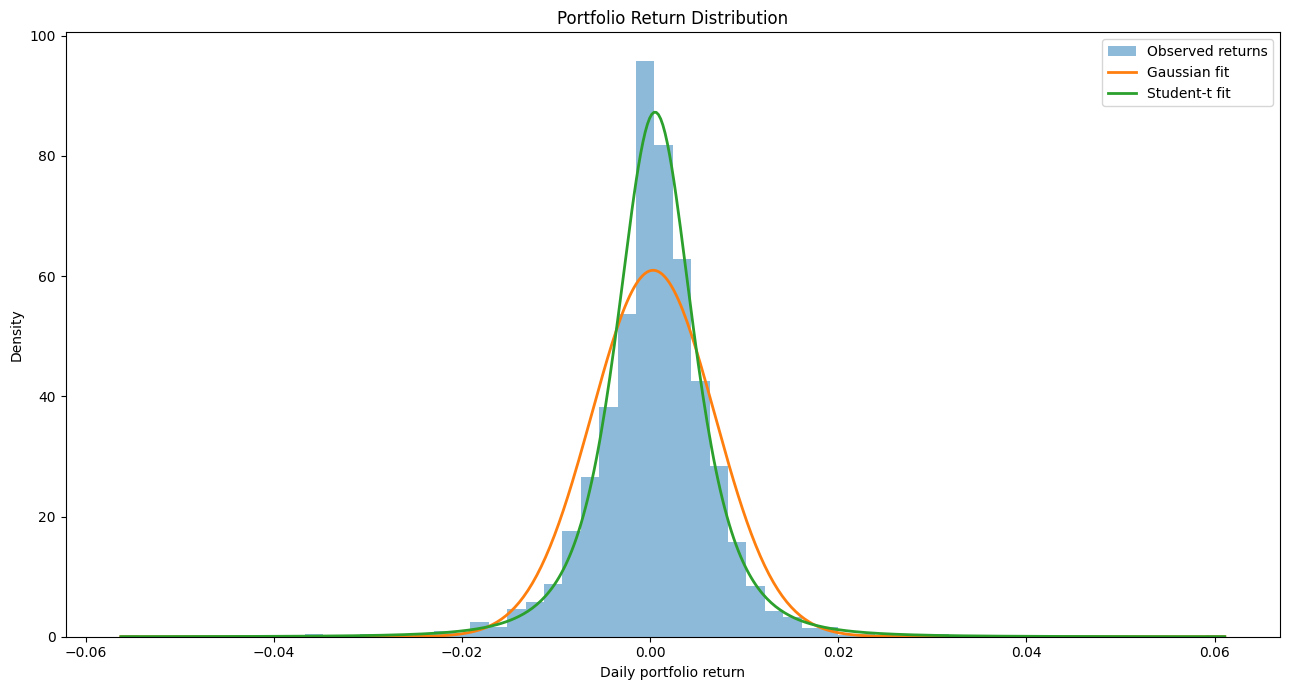

In [ ]:
x_values = np.linspace(
    portfolio_returns.min(),
    portfolio_returns.max(),
    500,
)

gaussian_mean = float(
    portfolio_returns.mean()
)

gaussian_std = float(
    portfolio_returns.std(ddof=1)
)

gaussian_density = norm.pdf(
    x_values,
    loc=gaussian_mean,
    scale=gaussian_std,
)

student_density = t.pdf(
    x_values,
    df=student_t_parameters[
        "degrees_of_freedom"
    ],
    loc=student_t_parameters[
        "location"
    ],
    scale=student_t_parameters[
        "scale"
    ],
)

plt.figure(figsize=(13, 7))

plt.hist(
    portfolio_returns,
    bins=60,
    density=True,
    alpha=0.5,
    label="Observed returns",
)

plt.plot(
    x_values,
    gaussian_density,
    linewidth=2,
    label="Gaussian fit",
)

plt.plot(
    x_values,
    student_density,
    linewidth=2,
    label="Student-t fit",
)

plt.title(
    "Portfolio Return Distribution"
)

plt.xlabel("Daily portfolio return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## Comparaison graphique des VaR

### VaR à 99 %

In [ ]:
var_99_comparison = (
    static_risk_metrics[
        static_risk_metrics[
            "confidence_level"
        ]
        == PRIMARY_CONFIDENCE_LEVEL
    ]
    .sort_values(
        "var_amount",
        ascending=False,
    )
)

var_99_comparison[
    [
        "model",
        "var_amount",
        "es_amount",
    ]
]

,model,var_amount,es_amount
10,Historical,"35,717.607647","52,141.525763"
12,Student-t,"34,621.196425","51,703.737037"
13,Monte Carlo Student-t,"34,442.076766","50,184.093055"
14,EWMA Gaussian,"29,900.817913",NaN
11,Gaussian,"29,774.887392","34,208.695162"


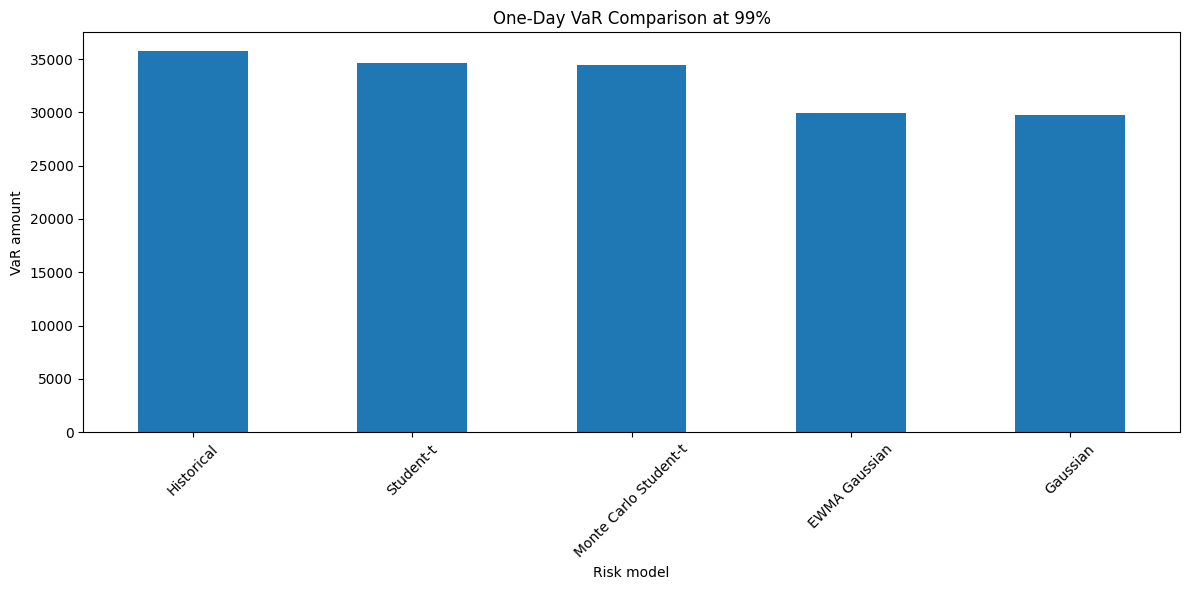

In [ ]:
var_99_comparison.set_index(
    "model"
)["var_amount"].plot(
    kind="bar",
    figsize=(12, 6),
    title="One-Day VaR Comparison at 99%",
)

plt.xlabel("Risk model")
plt.ylabel("VaR amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Comparaison VaR et ES

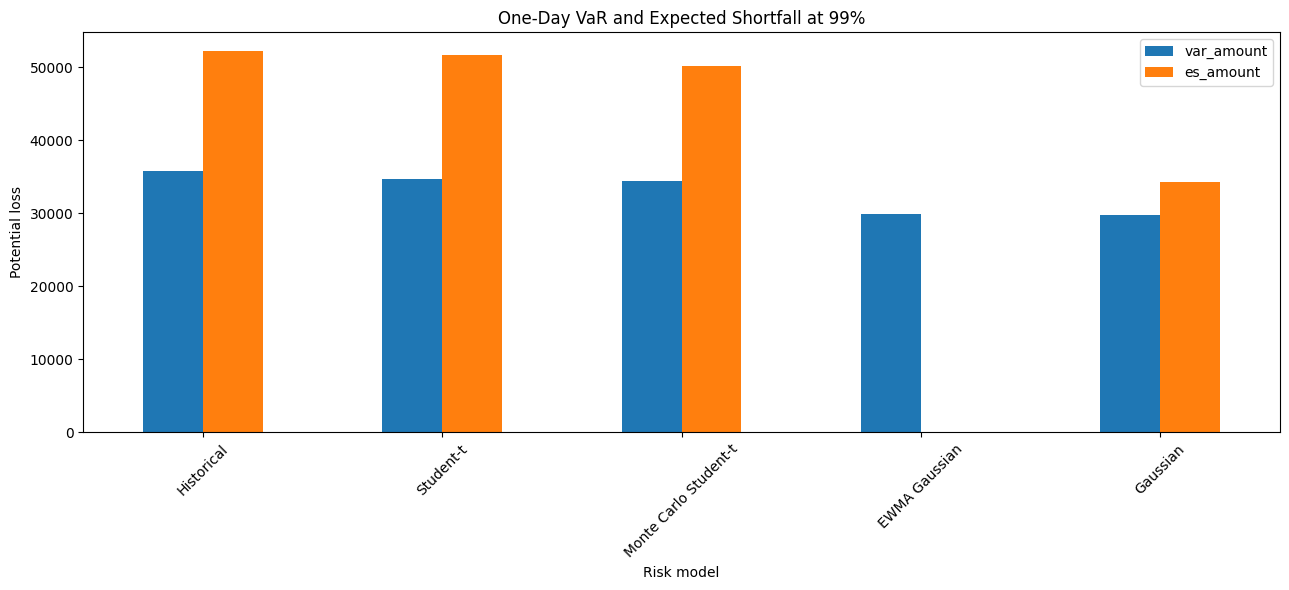

In [ ]:
var_es_99 = (
    var_99_comparison[
        [
            "model",
            "var_amount",
            "es_amount",
        ]
    ]
    .set_index("model")
)

var_es_99.plot(
    kind="bar",
    figsize=(13, 6),
    title=(
        "One-Day VaR and Expected "
        "Shortfall at 99%"
    ),
)

plt.xlabel("Risk model")
plt.ylabel("Potential loss")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Identification des observations de queue

### Pertes extrêmes historiques

In [ ]:
historical_99_result = historical_var(
    returns=portfolio_returns,
    confidence_level=0.99,
    portfolio_value=CURRENT_PORTFOLIO_VALUE,
)

historical_99_quantile = (
    historical_99_result[
        "return_quantile"
    ]
)

tail_loss_observations = pd.DataFrame({
    "portfolio_return":
        portfolio_returns,

    "daily_pnl":
        portfolio_daily_pnl.reindex(
            portfolio_returns.index
        ),

    "portfolio_value":
        portfolio_value.reindex(
            portfolio_returns.index
        ),
})

tail_loss_observations = (
    tail_loss_observations[
        tail_loss_observations[
            "portfolio_return"
        ]
        <= historical_99_quantile
    ]
    .sort_values(
        "portfolio_return"
    )
)

tail_loss_observations

,portfolio_return,daily_pnl,portfolio_value
date,,,
2020-03-12,-0.056249,"-58,860.168697","987,557.736354"
2020-03-16,-0.042816,"-43,585.649785","974,380.536346"
2020-03-18,-0.038455,"-37,791.384916","944,961.890162"
2020-03-09,-0.036313,"-40,334.488824","1,070,411.259287"
2025-04-04,-0.035539,"-56,436.476112","1,531,564.947259"
2020-03-11,-0.029696,"-32,025.250554","1,046,417.905052"
2022-06-13,-0.028977,"-34,244.324790","1,147,531.269118"
2020-06-11,-0.027823,"-31,927.742639","1,115,610.202141"
2022-09-13,-0.024504,"-28,926.666491","1,151,561.663026"


## Prévisions glissantes sans biais d’anticipation

Cette partie est essentielle pour le notebook 4.

Pour prévoir la VaR du jour t, on doit uniquement utiliser les informations disponibles jusqu’au jour t−1.

Nous allons donc appliquer systématiquement un décalage avec :

In [ ]:
portfolio_returns.shift(1)

,portfolio_return
date,
2018-01-03,NaN
2018-01-04,0.003015
2018-01-05,0.004542
2018-01-08,0.003795
2018-01-09,-0.000743
...,...
2026-07-23,0.001578
2026-07-24,-0.012318
2026-07-27,0.002163


### Fonction de VaR historique glissante

In [ ]:
def rolling_historical_var(
    returns: pd.Series,
    confidence_level: float,
    window: int,
) -> pd.Series:
    """
    Calculate one-day-ahead rolling historical VaR.

    The forecast at date t uses returns available
    only through date t-1.
    """

    alpha = 1 - confidence_level

    forecast = (
        returns
        .shift(1)
        .rolling(
            window=window,
            min_periods=window,
        )
        .quantile(alpha)
        .mul(-1)
        .clip(lower=0)
    )

    forecast.name = (
        f"historical_var_"
        f"{int(confidence_level * 1000):03d}"
    )

    return forecast

### Fonction normale glissante

In [ ]:
def rolling_gaussian_var(
    returns: pd.Series,
    confidence_level: float,
    window: int,
) -> pd.Series:
    """Calculate one-day-ahead Gaussian rolling VaR."""

    alpha = 1 - confidence_level
    z_alpha = norm.ppf(alpha)

    lagged_returns = returns.shift(1)

    rolling_mean = (
        lagged_returns
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    rolling_volatility = (
        lagged_returns
        .rolling(
            window=window,
            min_periods=window,
        )
        .std(ddof=1)
    )

    return_quantile = (
        rolling_mean
        + rolling_volatility
        * z_alpha
    )

    forecast = (
        -return_quantile
    ).clip(lower=0)

    forecast.name = (
        f"gaussian_var_"
        f"{int(confidence_level * 1000):03d}"
    )

    return forecast

### Expected Shortfall historique glissant

In [ ]:
def rolling_historical_es(
    returns: pd.Series,
    confidence_level: float,
    window: int,
) -> pd.Series:
    """Calculate rolling historical Expected Shortfall."""

    alpha = 1 - confidence_level

    lagged_returns = returns.shift(1)

    def calculate_window_es(
        window_values: np.ndarray,
    ) -> float:

        return_quantile = np.quantile(
            window_values,
            alpha,
        )

        tail = window_values[
            window_values
            <= return_quantile
        ]

        if len(tail) == 0:
            return np.nan

        return max(
            -float(np.mean(tail)),
            0.0,
        )

    forecast = (
        lagged_returns
        .rolling(
            window=window,
            min_periods=window,
        )
        .apply(
            calculate_window_es,
            raw=True,
        )
    )

    forecast.name = (
        f"historical_es_"
        f"{int(confidence_level * 1000):03d}"
    )

    return forecast

### VaR EWMA glissante

In [ ]:
def rolling_ewma_var(
    returns: pd.Series,
    confidence_level: float,
    decay_factor: float = 0.94,
) -> pd.Series:
    """Calculate one-day-ahead EWMA Gaussian VaR."""

    clean_returns = (
        pd.Series(returns)
        .dropna()
        .astype(float)
    )

    alpha = 1 - confidence_level
    z_alpha = norm.ppf(alpha)

    ewma_volatility = calculate_ewma_volatility(
        returns=clean_returns,
        decay_factor=decay_factor,
    )

    forecast_volatility = (
        ewma_volatility.shift(1)
    )

    mean_forecast = (
        clean_returns
        .shift(1)
        .expanding(
            min_periods=30
        )
        .mean()
    )

    return_quantile = (
        mean_forecast
        + forecast_volatility
        * z_alpha
    )

    forecast = (
        -return_quantile
    ).clip(lower=0)

    forecast.name = (
        f"ewma_var_"
        f"{int(confidence_level * 1000):03d}"
    )

    return forecast

## Construire le tableau des prévisions glissantes

### Prévisions en rendement

In [ ]:
rolling_risk_forecasts = pd.DataFrame(
    index=portfolio_returns.index
)

for confidence_level in [
    0.95,
    0.99,
]:

    confidence_suffix = int(
        confidence_level * 100
    )

    rolling_risk_forecasts[
        f"historical_var_{confidence_suffix}"
    ] = rolling_historical_var(
        returns=portfolio_returns,
        confidence_level=confidence_level,
        window=HISTORICAL_WINDOW,
    )

    rolling_risk_forecasts[
        f"gaussian_var_{confidence_suffix}"
    ] = rolling_gaussian_var(
        returns=portfolio_returns,
        confidence_level=confidence_level,
        window=HISTORICAL_WINDOW,
    )

    rolling_risk_forecasts[
        f"ewma_var_{confidence_suffix}"
    ] = rolling_ewma_var(
        returns=portfolio_returns,
        confidence_level=confidence_level,
        decay_factor=EWMA_DECAY_FACTOR,
    )

    rolling_risk_forecasts[
        f"historical_es_{confidence_suffix}"
    ] = rolling_historical_es(
        returns=portfolio_returns,
        confidence_level=confidence_level,
        window=HISTORICAL_WINDOW,
    )

rolling_risk_forecasts.dropna().head()

,historical_var_95,gaussian_var_95,ewma_var_95,historical_es_95,historical_var_99,gaussian_var_99,ewma_var_99,historical_es_99
date,,,,,,,,
2018-12-19,0.007666,0.007416,0.008673,0.011007,0.012722,0.010396,0.012175,0.015780
2018-12-20,0.007666,0.007458,0.008467,0.011007,0.012722,0.010442,0.011875,0.015780
2018-12-21,0.007666,0.007485,0.008489,0.011007,0.012722,0.010467,0.011900,0.015780
2018-12-24,0.007666,0.007555,0.008433,0.011007,0.012722,0.010547,0.011809,0.015780
2018-12-25,0.007781,0.007646,0.008759,0.011108,0.012722,0.010661,0.012255,0.015780


### Ajouter rendements, P&L et valeur du portefeuille

In [ ]:
rolling_risk_forecasts[
    "portfolio_return"
] = portfolio_returns

rolling_risk_forecasts[
    "daily_pnl"
] = portfolio_daily_pnl.reindex(
    rolling_risk_forecasts.index
)

rolling_risk_forecasts[
    "portfolio_value_previous_day"
] = (
    portfolio_value
    .shift(1)
    .reindex(
        rolling_risk_forecasts.index
    )
)

rolling_risk_forecasts.dropna().head()

,historical_var_95,gaussian_var_95,ewma_var_95,historical_es_95,historical_var_99,gaussian_var_99,ewma_var_99,historical_es_99,portfolio_return,daily_pnl,portfolio_value_previous_day
date,,,,,,,,,,,
2018-12-19,0.007666,0.007416,0.008673,0.011007,0.012722,0.010396,0.012175,0.015780,-0.005068,"-4,783.042328","943,757.767325"
2018-12-20,0.007666,0.007458,0.008467,0.011007,0.012722,0.010442,0.011875,0.015780,-0.004071,"-3,822.240676","938,974.724998"
2018-12-21,0.007666,0.007485,0.008489,0.011007,0.012722,0.010467,0.011900,0.015780,-0.007368,"-6,890.404861","935,152.484322"
2018-12-24,0.007666,0.007555,0.008433,0.011007,0.012722,0.010547,0.011809,0.015780,-0.009091,"-8,439.267184","928,262.079461"
2018-12-25,0.007781,0.007646,0.008759,0.011108,0.012722,0.010661,0.012255,0.015780,0.000282,259.139426,"919,822.812277"


### Convertir les prévisions en montants

In [ ]:
risk_return_columns = [
    column
    for column in rolling_risk_forecasts.columns
    if (
        "var_" in column
        or "es_" in column
    )
]

for column in risk_return_columns:
    rolling_risk_forecasts[
        f"{column}_amount"
    ] = (
        rolling_risk_forecasts[column]
        * rolling_risk_forecasts[
            "portfolio_value_previous_day"
        ]
    )

rolling_risk_forecasts.tail()

,historical_var_95,gaussian_var_95,ewma_var_95,historical_es_95,historical_var_99,gaussian_var_99,ewma_var_99,historical_es_99,portfolio_return,daily_pnl,portfolio_value_previous_day,historical_var_95_amount,gaussian_var_95_amount,ewma_var_95_amount,historical_es_95_amount,historical_var_99_amount,gaussian_var_99_amount,ewma_var_99_amount,historical_es_99_amount
date,,,,,,,,,,,,,,,,,,,
2026-07-23,0.011839,0.010910,0.010961,0.016385,0.019363,0.015672,0.015642,0.021437,-0.012318,"-24,813.268222","2,014,322.515571","23,848.079302","21,976.329049","22,079.315671","33,005.608297","39,002.859642","31,567.789746","31,507.558185","43,181.011804"
2026-07-24,0.012199,0.011030,0.010641,0.016398,0.019363,0.015824,0.015187,0.021437,0.002163,"4,303.059533","1,989,509.247349","24,269.326708","21,945.059238","21,170.612432","32,623.944607","38,522.406085","31,481.381978","30,214.226530","42,649.090019"
2026-07-27,0.012199,0.011033,0.011407,0.016398,0.019363,0.015825,0.016270,0.021437,0.003289,"6,557.817640","1,993,812.306882","24,321.818225","21,998.563065","22,743.359366","32,694.506117","38,605.725229","31,551.584258","32,439.860497","42,741.334664"
2026-07-28,0.012199,0.011034,0.011081,0.016398,0.019363,0.015825,0.015810,0.021437,-0.000612,"-1,223.505922","2,000,370.124522","24,401.814746","22,072.211365","22,166.844947","32,802.041118","38,732.702731","31,655.310895","31,626.484056","42,881.914536"
2026-07-29,0.012199,0.011047,0.010813,0.016398,0.019363,0.015836,0.015431,0.021437,0.000143,286.044829,"1,999,146.618600","24,386.889626","22,083.619905","21,617.072832","32,781.978085","38,709.012270","31,658.588434","30,848.411873","42,855.686251"


## Contrôle du biais d’anticipation

### Vérification logique

In [ ]:
first_valid_historical_var_date = (
    rolling_risk_forecasts[
        "historical_var_99"
    ]
    .first_valid_index()
)

expected_minimum_position = (
    HISTORICAL_WINDOW
)

actual_position = (
    portfolio_returns.index
    .get_loc(
        first_valid_historical_var_date
    )
)

print(
    "First valid historical VaR date:",
    first_valid_historical_var_date.date(),
)

print(
    "Position in return series:",
    actual_position,
)

assert (
    actual_position
    >= expected_minimum_position
)

print(
    "Rolling forecast lag validation successful."
)

First valid historical VaR date: 2018-12-19
Position in return series: 250
Rolling forecast lag validation successful.


## Visualisation des prévisions glissantes

### VaR historique à 99 % contre P&L

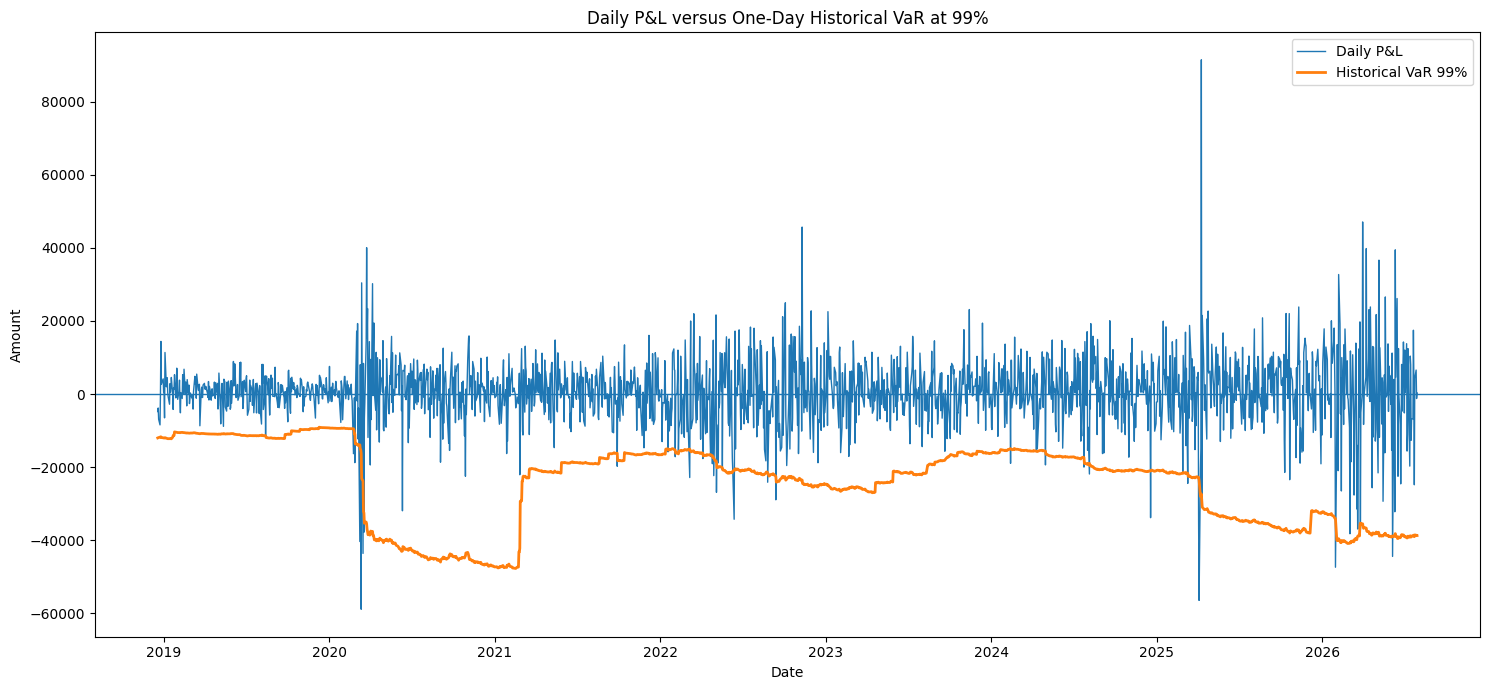

In [ ]:
rolling_plot_data = (
    rolling_risk_forecasts[
        [
            "daily_pnl",
            "historical_var_99_amount",
        ]
    ]
    .dropna()
)

plt.figure(figsize=(15, 7))

plt.plot(
    rolling_plot_data.index,
    rolling_plot_data["daily_pnl"],
    label="Daily P&L",
    linewidth=1,
)

plt.plot(
    rolling_plot_data.index,
    -rolling_plot_data[
        "historical_var_99_amount"
    ],
    label="Historical VaR 99%",
    linewidth=2,
)

plt.axhline(
    y=0,
    linewidth=1,
)

plt.title(
    "Daily P&L versus One-Day "
    "Historical VaR at 99%"
)

plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.show()

### Comparaison des modèles glissants

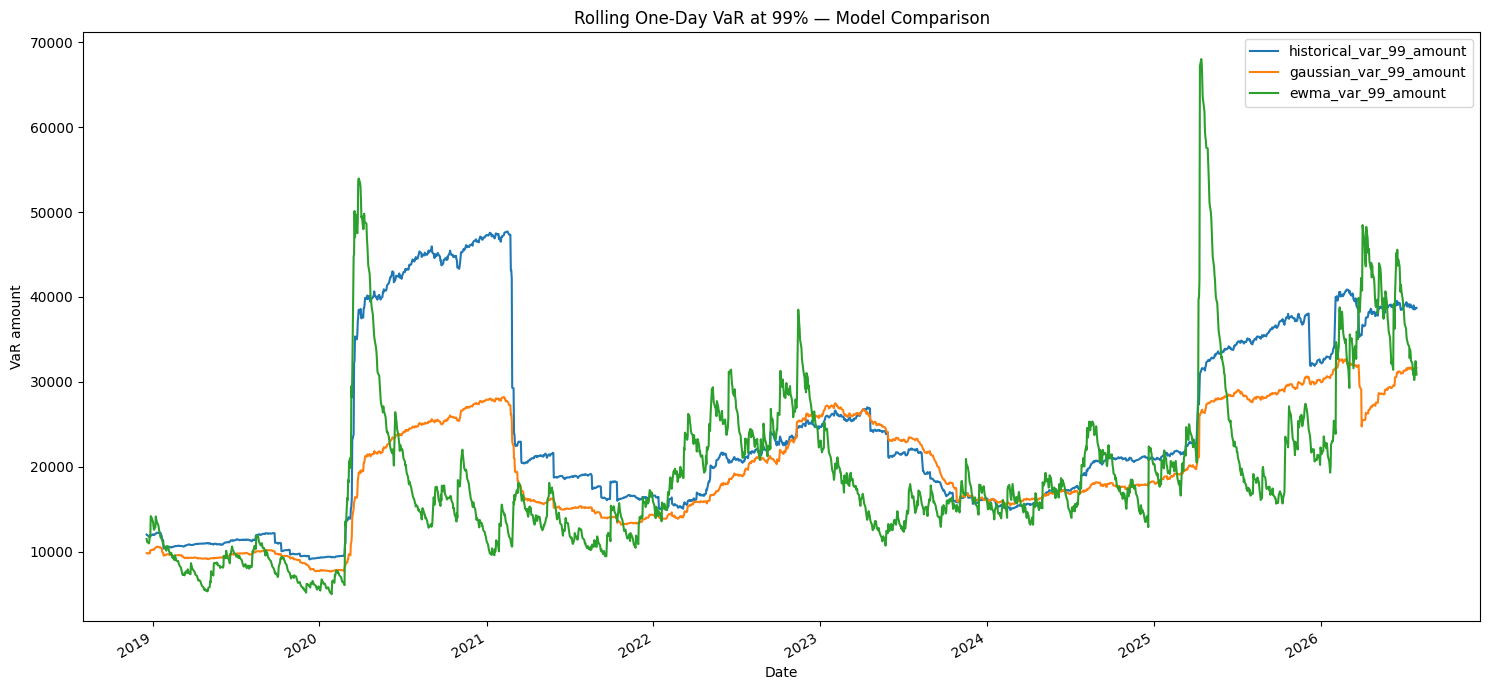

In [ ]:
rolling_model_comparison = (
    rolling_risk_forecasts[
        [
            "historical_var_99_amount",
            "gaussian_var_99_amount",
            "ewma_var_99_amount",
        ]
    ]
    .dropna()
)

rolling_model_comparison.plot(
    figsize=(15, 7),
    title=(
        "Rolling One-Day VaR at 99% "
        "— Model Comparison"
    ),
)

plt.xlabel("Date")
plt.ylabel("VaR amount")
plt.tight_layout()
plt.show()

## Synthèse des modèles

### Tableau de comparaison

In [ ]:
var_model_comparison = (
    static_risk_metrics
    .pivot_table(
        index="model",
        columns="confidence_level",
        values=[
            "var_amount",
            "es_amount",
        ],
    )
)

var_model_comparison

es_amount                                var_amount  \
confidence_level           0.950000      0.975000      0.990000      0.950000   
model                                                                           
EWMA Gaussian                   NaN           NaN           NaN 20,947.094461   
Gaussian              26,325.423557 29,924.766262 34,208.695162 20,858.054779   
Historical            30,799.643241 39,084.447355 52,141.525763 19,364.375208   
Monte Carlo Student-t 29,008.571879 37,145.105014 50,184.093055 18,157.339007   
Student-t             29,372.716000 37,855.522283 51,703.737037 18,141.389047   

                                                   
confidence_level           0.975000      0.990000  
model                                              
EWMA Gaussian         25,087.130875 29,900.817913  
Gaussian              24,981.033550 29,774.887392  
Historical            26,305.831010 35,717.607647  
Monte Carlo Student-t 24,396.764643 34,442.076766  
Student-t             24,515.161923 34,621.196425

In [ ]:
primary_model_comparison = (
    static_risk_metrics[
        static_risk_metrics[
            "confidence_level"
        ]
        == PRIMARY_CONFIDENCE_LEVEL
    ]
    .copy()
)

primary_model_comparison[
    "es_var_ratio"
] = (
    primary_model_comparison[
        "es_amount"
    ]
    / primary_model_comparison[
        "var_amount"
    ]
)

primary_model_comparison = (
    primary_model_comparison.sort_values(
        "var_amount",
        ascending=False,
    )
)

primary_model_comparison

,model,confidence_level,var_return,var_amount,es_return,es_amount,es_var_ratio
10,Historical,0.990000,0.017864,"35,717.607647",0.026078,"52,141.525763",1.459827
12,Student-t,0.990000,0.017316,"34,621.196425",0.025859,"51,703.737037",1.493413
13,Monte Carlo Student-t,0.990000,0.017226,"34,442.076766",0.025099,"50,184.093055",1.457058
14,EWMA Gaussian,0.990000,0.014955,"29,900.817913",NaN,NaN,NaN
11,Gaussian,0.990000,0.014892,"29,774.887392",0.017109,"34,208.695162",1.148911


## Validation des prévisions glissantes

### Fonction de validation

In [ ]:
def validate_rolling_risk_forecasts(
    forecasts: pd.DataFrame,
) -> None:
    """Validate rolling VaR and ES forecasts."""

    required_columns = {
        "portfolio_return",
        "daily_pnl",
        "portfolio_value_previous_day",
        "historical_var_99",
        "gaussian_var_99",
        "ewma_var_99",
        "historical_es_99",
        "historical_var_99_amount",
        "gaussian_var_99_amount",
        "ewma_var_99_amount",
        "historical_es_99_amount",
    }

    missing_columns = (
        required_columns
        - set(forecasts.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing rolling forecast columns: "
            f"{sorted(missing_columns)}"
        )

    risk_columns = [
        column
        for column in forecasts.columns
        if (
            "var_" in column
            or "es_" in column
        )
    ]

    for column in risk_columns:
        valid_values = forecasts[
            column
        ].dropna()

        if valid_values.lt(0).any():
            raise ValueError(
                f"Negative risk forecasts "
                f"detected in {column}."
            )

        if not np.isfinite(
            valid_values.to_numpy()
        ).all():
            raise ValueError(
                f"Non-finite values detected "
                f"in {column}."
            )

    common_data = forecasts[
        [
            "historical_var_99",
            "historical_es_99",
        ]
    ].dropna()

    if (
        common_data["historical_es_99"]
        < common_data["historical_var_99"]
    ).any():
        raise ValueError(
            "Historical ES is below historical VaR."
        )

    print(
        "Rolling risk forecast validation successful."
    )


validate_rolling_risk_forecasts(
    rolling_risk_forecasts
)

Rolling risk forecast validation successful.


## Enregistrer les sorties

### Définir les fichiers

In [ ]:
NOTEBOOK_03_OUTPUTS = {
    "static_risk_metrics_csv": (
        REPORTS_DIR
        / "static_risk_metrics.csv"
    ),

    "static_risk_metrics_parquet": (
        DATA_PROCESSED_DIR
        / "static_risk_metrics.parquet"
    ),

    "rolling_risk_forecasts_csv": (
        DATA_PROCESSED_DIR
        / "rolling_risk_forecasts.csv"
    ),

    "rolling_risk_forecasts_parquet": (
        DATA_PROCESSED_DIR
        / "rolling_risk_forecasts.parquet"
    ),

    "var_model_comparison_csv": (
        REPORTS_DIR
        / "var_model_comparison.csv"
    ),

    "primary_model_comparison_csv": (
        REPORTS_DIR
        / "primary_model_comparison.csv"
    ),

    "tail_loss_observations_csv": (
        REPORTS_DIR
        / "tail_loss_observations.csv"
    ),

    "return_distribution_statistics_csv": (
        REPORTS_DIR
        / "return_distribution_statistics.csv"
    ),

    "student_t_parameters_json": (
        CONFIG_DIR
        / "student_t_parameters.json"
    ),
}

### Sauvegarder les fichiers

In [ ]:
static_risk_metrics.to_csv(
    NOTEBOOK_03_OUTPUTS[
        "static_risk_metrics_csv"
    ],
    index=False,
)

static_risk_metrics.to_parquet(
    NOTEBOOK_03_OUTPUTS[
        "static_risk_metrics_parquet"
    ],
    index=False,
)

rolling_risk_forecasts.to_csv(
    NOTEBOOK_03_OUTPUTS[
        "rolling_risk_forecasts_csv"
    ]
)

rolling_risk_forecasts.to_parquet(
    NOTEBOOK_03_OUTPUTS[
        "rolling_risk_forecasts_parquet"
    ]
)

var_model_comparison.to_csv(
    NOTEBOOK_03_OUTPUTS[
        "var_model_comparison_csv"
    ]
)

primary_model_comparison.to_csv(
    NOTEBOOK_03_OUTPUTS[
        "primary_model_comparison_csv"
    ],
    index=False,
)

tail_loss_observations.to_csv(
    NOTEBOOK_03_OUTPUTS[
        "tail_loss_observations_csv"
    ]
)

return_distribution_statistics.rename(
    "value"
).to_csv(
    NOTEBOOK_03_OUTPUTS[
        "return_distribution_statistics_csv"
    ]
)

with open(
    NOTEBOOK_03_OUTPUTS[
        "student_t_parameters_json"
    ],
    "w",
    encoding="utf-8",
) as parameter_file:
    json.dump(
        student_t_parameters,
        parameter_file,
        indent=4,
    )

print("Notebook 03 outputs saved successfully.")

Notebook 03 outputs saved successfully.


## Dépendances du notebook 4

### Définir les fichiers nécessaires

In [ ]:
NOTEBOOK_04_DEPENDENCIES = [
    NOTEBOOK_03_OUTPUTS[
        "rolling_risk_forecasts_parquet"
    ],

    NOTEBOOK_03_OUTPUTS[
        "static_risk_metrics_parquet"
    ],

    NOTEBOOK_02_REQUIRED_FILES[
        "portfolio_timeseries"
    ],

    NOTEBOOK_02_REQUIRED_FILES[
        "portfolio_weights"
    ],

    NOTEBOOK_02_REQUIRED_FILES[
        "portfolio_positions"
    ],
]

### Calculer les empreintes

In [ ]:
notebook_03_hashes = {
    file_path.name:
        calculate_file_hash(file_path)

    for file_path
    in NOTEBOOK_04_DEPENDENCIES
}

notebook_03_hashes

{'rolling_risk_forecasts.parquet': 'aa50c5589610db0f4635046115e0091297933278b5aec99df51cf5ed7bcf8213',
 'static_risk_metrics.parquet': 'c0411358656a2313f68a323a2948e2084c0a321eed326040d77d8fe7e71bca41',
 'portfolio_timeseries.parquet': '8ad5b57011be9abe8da80b2ac2a055acb3a344a7fd88ae806c42aa8252f2f5f1',
 'portfolio_weights.csv': '30770211096b759793962fb08d9985f0005e49940526f38bf1a86b5f187fdfd8',
 'portfolio_positions.csv': '69b82696d83bef987a317995150b37f56c8319f8aa00bac280ca75fcc830ba3c'}

### Manifeste du notebook 3

### Créer le manifeste

In [ ]:
NOTEBOOK_03_MANIFEST_PATH = (
    CONFIG_DIR
    / "notebook_03_manifest.json"
)

generation_time = datetime.now(
    timezone.utc
).isoformat()

notebook_03_manifest = {
    "pipeline_name":
        "Market Risk Analytics Platform",

    "pipeline_version":
        notebook_02_manifest[
            "pipeline_version"
        ],

    "producer_notebook":
        "03_var_and_expected_shortfall.ipynb",

    "upstream_notebook":
        notebook_02_manifest[
            "producer_notebook"
        ],

    "upstream_manifest":
        str(
            NOTEBOOK_02_REQUIRED_FILES[
                "manifest"
            ]
            .relative_to(PROJECT_ROOT)
        ),

    "generated_at_utc":
        generation_time,

    "portfolio_name":
        notebook_02_manifest[
            "portfolio_name"
        ],

    "current_portfolio_value":
        CURRENT_PORTFOLIO_VALUE,

    "risk_horizon_days":
        RISK_HORIZON_DAYS,

    "confidence_levels":
        CONFIDENCE_LEVELS,

    "primary_confidence_level":
        PRIMARY_CONFIDENCE_LEVEL,

    "historical_window":
        HISTORICAL_WINDOW,

    "ewma_decay_factor":
        EWMA_DECAY_FACTOR,

    "monte_carlo_simulations":
        MONTE_CARLO_SIMULATIONS,

    "implemented_models": [
        "Historical",
        "Gaussian",
        "Student-t",
        "Monte Carlo Student-t",
        "EWMA Gaussian",
    ],

    "return_observations":
        int(len(portfolio_returns)),

    "rolling_forecast_observations":
        int(
            rolling_risk_forecasts[
                "historical_var_99"
            ]
            .notna()
            .sum()
        ),

    "student_t_parameters":
        student_t_parameters,

    "notebook_04_dependencies": [
        str(
            file_path.relative_to(
                PROJECT_ROOT
            )
        )
        for file_path
        in NOTEBOOK_04_DEPENDENCIES
    ],

    "file_hashes":
        notebook_03_hashes,

    "status":
        "SUCCESS",
}

with open(
    NOTEBOOK_03_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        notebook_03_manifest,
        manifest_file,
        indent=4,
        ensure_ascii=False,
    )

print(
    "Notebook 03 manifest saved to:",
    NOTEBOOK_03_MANIFEST_PATH,
)

Notebook 03 manifest saved to: /content/drive/MyDrive/market-risk-analytics/config/notebook_03_manifest.json


## Validation des dépendances du notebook 4

### Validation finale

In [ ]:
def validate_notebook_03_outputs(
    required_files: list[Path],
    manifest_path: Path,
) -> None:
    """Validate outputs required by Notebook 04."""

    missing_files = [
        file_path
        for file_path in required_files
        if not file_path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Notebook 03 failed to create: "
            f"{missing_files}"
        )

    empty_files = [
        file_path
        for file_path in required_files
        if file_path.stat().st_size == 0
    ]

    if empty_files:
        raise ValueError(
            "Empty Notebook 03 outputs: "
            f"{empty_files}"
        )

    if not manifest_path.exists():
        raise FileNotFoundError(
            "Notebook 03 manifest "
            "was not created."
        )

    with open(
        manifest_path,
        "r",
        encoding="utf-8",
    ) as manifest_file:
        manifest = json.load(
            manifest_file
        )

    if manifest.get("status") != "SUCCESS":
        raise RuntimeError(
            "Notebook 03 manifest does "
            "not report SUCCESS."
        )

    if manifest.get("producer_notebook") != (
        "03_var_and_expected_shortfall.ipynb"
    ):
        raise RuntimeError(
            "Unexpected producer notebook."
        )

    print(
        "All Notebook 03 dependencies are valid."
    )

    print(
        "Notebook 04 can now be executed."
    )


validate_notebook_03_outputs(
    required_files=NOTEBOOK_04_DEPENDENCIES,
    manifest_path=NOTEBOOK_03_MANIFEST_PATH,
)

All Notebook 03 dependencies are valid.
Notebook 04 can now be executed.


## Test de rechargement

### Simuler le notebook 4

In [ ]:
reloaded_rolling_forecasts = pd.read_parquet(
    NOTEBOOK_03_OUTPUTS[
        "rolling_risk_forecasts_parquet"
    ]
)

reloaded_static_metrics = pd.read_parquet(
    NOTEBOOK_03_OUTPUTS[
        "static_risk_metrics_parquet"
    ]
)

assert (
    reloaded_rolling_forecasts.shape
    == rolling_risk_forecasts.shape
)

assert (
    reloaded_static_metrics.shape
    == static_risk_metrics.shape
)

assert (
    "historical_var_99_amount"
    in reloaded_rolling_forecasts.columns
)

assert (
    "daily_pnl"
    in reloaded_rolling_forecasts.columns
)

print("Notebook 04 loading test successful.")

print(
    "Rolling forecasts:",
    reloaded_rolling_forecasts.shape,
)

print(
    "Static metrics:",
    reloaded_static_metrics.shape,
)

Notebook 04 loading test successful.
Rolling forecasts: (2232, 19)
Static metrics: (15, 6)


## Résumé final

### Tableau récapitulatif

In [ ]:
historical_var_99_amount = (
    static_risk_metrics.loc[
        (
            static_risk_metrics["model"]
            == "Historical"
        )
        & (
            static_risk_metrics[
                "confidence_level"
            ]
            == 0.99
        ),
        "var_amount",
    ]
    .iloc[0]
)

historical_es_99_amount = (
    static_risk_metrics.loc[
        (
            static_risk_metrics["model"]
            == "Historical"
        )
        & (
            static_risk_metrics[
                "confidence_level"
            ]
            == 0.99
        ),
        "es_amount",
    ]
    .iloc[0]
)

notebook_03_summary = pd.DataFrame({
    "indicator": [
        "Pipeline status",
        "Portfolio value",
        "Return observations",
        "Risk horizon",
        "Historical window",
        "Monte Carlo simulations",
        "Historical VaR 99%",
        "Historical ES 99%",
        "Student-t degrees of freedom",
        "Rolling forecast observations",
        "Files required by Notebook 04",
    ],

    "value": [
        "SUCCESS",
        CURRENT_PORTFOLIO_VALUE,
        len(portfolio_returns),
        f"{RISK_HORIZON_DAYS} day",
        HISTORICAL_WINDOW,
        MONTE_CARLO_SIMULATIONS,
        historical_var_99_amount,
        historical_es_99_amount,
        student_t_parameters[
            "degrees_of_freedom"
        ],
        rolling_risk_forecasts[
            "historical_var_99"
        ].notna().sum(),
        len(NOTEBOOK_04_DEPENDENCIES),
    ],
})

notebook_03_summary

,indicator,value
0,Pipeline status,SUCCESS
1,Portfolio value,"1,999,432.663429"
2,Return observations,2232
3,Risk horizon,1 day
4,Historical window,250
5,Monte Carlo simulations,100000
6,Historical VaR 99%,"35,717.607647"
7,Historical ES 99%,"52,141.525763"
8,Student-t degrees of freedom,3.324409
9,Rolling forecast observations,1982


In [ ]:
print(f"Listing files in {DATA_PROCESSED_DIR}:")
!ls -l {DATA_PROCESSED_DIR}

Listing files in /content/drive/MyDrive/market-risk-analytics/data/processed:
total 6728
-rw------- 1 root root  139320 Jul 29 05:55 asset_pnl_contributions.parquet
-rw------- 1 root root  687557 Jul 28 22:35 final_dashboard_data.csv
-rw------- 1 root root  351158 Jul 28 22:35 final_dashboard_data.parquet
-rw------- 1 root root    4648 Jul 28 20:33 hypothetical_stress_results.parquet
-rw------- 1 root root  308517 Jul 29 05:53 market_log_returns.csv
-rw------- 1 root root  148269 Jul 29 05:53 market_log_returns.parquet
-rw------- 1 root root  268500 Jul 29 05:53 market_prices.csv
-rw------- 1 root root  113060 Jul 29 05:53 market_prices.parquet
-rw------- 1 root root  308541 Jul 29 05:53 market_returns.csv
-rw------- 1 root root  148269 Jul 29 05:53 market_returns.parquet
-rw------- 1 root root  151392 Jul 28 22:35 pca_scores.parquet
-rw------- 1 root root    1046 Jul 29 05:55 portfolio_positions.csv
-rw------- 1 root root  328896 Jul 29 05:55 portfolio_timeseries.csv
-rw------- 1 root

In [ ]:
file_to_check = DATA_PROCESSED_DIR / "actual_portfolio_weights.parquet"

if file_to_check.exists():
    print(f"Le fichier {file_to_check.name} existe.")
else:
    print(f"Le fichier {file_to_check.name} n'existe PAS, ce qui est normal car il ne fait pas partie des dépendances définies pour ce notebook.")


print(f"\nLe fichier de dépendance pour les poids du portefeuille est : {NOTEBOOK_02_REQUIRED_FILES['portfolio_weights'].name}")
print(f"Ce fichier a été chargé avec succès et a une forme de: {portfolio_weights.shape}")

Le fichier actual_portfolio_weights.parquet n'existe PAS, ce qui est normal car il ne fait pas partie des dépendances définies pour ce notebook.

Le fichier de dépendance pour les poids du portefeuille est : portfolio_weights.csv
Ce fichier a été chargé avec succès et a une forme de: (6,)


In [ ]:
print(f"Listing files in {DATA_PROCESSED_DIR}:")
!ls -l {DATA_PROCESSED_DIR}

Listing files in /content/drive/MyDrive/market-risk-analytics/data/processed:
total 6728
-rw------- 1 root root  139320 Jul 29 05:55 asset_pnl_contributions.parquet
-rw------- 1 root root  687557 Jul 28 22:35 final_dashboard_data.csv
-rw------- 1 root root  351158 Jul 28 22:35 final_dashboard_data.parquet
-rw------- 1 root root    4648 Jul 28 20:33 hypothetical_stress_results.parquet
-rw------- 1 root root  308517 Jul 29 05:53 market_log_returns.csv
-rw------- 1 root root  148269 Jul 29 05:53 market_log_returns.parquet
-rw------- 1 root root  268500 Jul 29 05:53 market_prices.csv
-rw------- 1 root root  113060 Jul 29 05:53 market_prices.parquet
-rw------- 1 root root  308541 Jul 29 05:53 market_returns.csv
-rw------- 1 root root  148269 Jul 29 05:53 market_returns.parquet
-rw------- 1 root root  151392 Jul 28 22:35 pca_scores.parquet
-rw------- 1 root root    1046 Jul 29 05:55 portfolio_positions.csv
-rw------- 1 root root  328896 Jul 29 05:55 portfolio_timeseries.csv
-rw------- 1 root

In [ ]:
print(f"Listing files in {DATA_PROCESSED_DIR}:")
!ls -l {DATA_PROCESSED_DIR}

Listing files in /content/drive/MyDrive/market-risk-analytics/data/processed:
total 6728
-rw------- 1 root root  139320 Jul 29 05:55 asset_pnl_contributions.parquet
-rw------- 1 root root  687557 Jul 28 22:35 final_dashboard_data.csv
-rw------- 1 root root  351158 Jul 28 22:35 final_dashboard_data.parquet
-rw------- 1 root root    4648 Jul 28 20:33 hypothetical_stress_results.parquet
-rw------- 1 root root  308517 Jul 29 05:53 market_log_returns.csv
-rw------- 1 root root  148269 Jul 29 05:53 market_log_returns.parquet
-rw------- 1 root root  268500 Jul 29 05:53 market_prices.csv
-rw------- 1 root root  113060 Jul 29 05:53 market_prices.parquet
-rw------- 1 root root  308541 Jul 29 05:53 market_returns.csv
-rw------- 1 root root  148269 Jul 29 05:53 market_returns.parquet
-rw------- 1 root root  151392 Jul 28 22:35 pca_scores.parquet
-rw------- 1 root root    1046 Jul 29 05:55 portfolio_positions.csv
-rw------- 1 root root  328896 Jul 29 05:55 portfolio_timeseries.csv
-rw------- 1 root

## Conclusion

Notebook 03 successfully implemented the principal market-risk measures required to assess the one-day loss exposure of the multi-asset portfolio.

### Models implemented

- Historical Value-at-Risk;
- Gaussian Parametric Value-at-Risk;
- Student-t Parametric Value-at-Risk;
- Student-t Monte Carlo Value-at-Risk;
- EWMA Gaussian Value-at-Risk;
- Historical Expected Shortfall;
- Gaussian Expected Shortfall;
- Student-t Expected Shortfall;
- Monte Carlo Expected Shortfall.

### Main methodological controls

- VaR and Expected Shortfall are reported as positive potential losses.
- Expected Shortfall was verified to be greater than or equal to VaR.
- Risk estimates were checked for monotonicity across confidence levels.
- Student-t parameters were estimated from portfolio returns.
- Monte Carlo simulations were made reproducible using a fixed random seed.
- Rolling forecasts use only information available through the previous trading day.
- Monetary risk forecasts use the previous day's portfolio value.
- This prevents look-ahead bias in the subsequent backtesting exercise.

### Main limitations

- The models use daily end-of-day returns.
- Intraday risk is not considered.
- Liquidity risk and transaction costs are excluded.
- The Gaussian model may underestimate heavy-tail risk.
- The Student-t model assumes a stable parametric distribution.
- Monte Carlo results depend on the selected distribution and calibration sample.
- The portfolio is treated as a set of linear positions.
- Option Greeks and nonlinear pricing effects are not yet included.

### Dependency created for Notebook 04

Notebook 04 must load and validate:

- `data/processed/rolling_risk_forecasts.parquet`;
- `data/processed/static_risk_metrics.parquet`;
- `data/processed/portfolio_timeseries.parquet`;
- `data/processed/portfolio_weights.csv`;
- `data/processed/portfolio_positions.csv`;
- `config/notebook_03_manifest.json`.

### Next step

Notebook 04 will perform:

- VaR exception identification;
- exception-rate analysis;
- Kupiec unconditional coverage test;
- Christoffersen independence test;
- conditional coverage testing;
- Basel traffic-light analysis;
- historical stress testing;
- hypothetical stress testing;
- asset-level stress-loss attribution.